In [1]:
"""
Fair Clustering Dataset Utilities
==================================
Two dataset sources for evaluating fair multi-attribute clustering:
  1. Synthetic data  — 3 protected attributes: Race(3) × Sex(2) × EducationTier(2) = 12 groups
  2. Folktables ACS  — 3 protected attributes: same structure, genuinely continuous features

The number of protected attributes is controlled by `n_protected_attrs` (2 or 3).
Using 3 attributes directly stresses balance constraints (more groups = harder feasibility)
and lets you study how group count affects G-PoF — directly relevant to your thesis.

Clustering features are always spatial/socioeconomic — never the protected attributes.
"""

import matplotlib.patches as mpatches

In [5]:
#pip install pandas geopandas folktables

In [6]:
#STATE_FIPS = {
#    'AL': '01', 'AK': '02', 'AZ': '04', 'AR': '05', 'CA': '06', 'CO': '08',
#    'CT': '09', 'DE': '10', 'FL': '12', 'GA': '13', 'HI': '15', 'ID': '16',
#    'IL': '17', 'IN': '18', 'IA': '19', 'KS': '20', 'KY': '21', 'LA': '22',
#    'ME': '23', 'MD': '24', 'MA': '25', 'MI': '26', 'MN': '27', 'MS': '28',
#    'MO': '29', 'MT': '30', 'NE': '31', 'NV': '32', 'NH': '33', 'NJ': '34',
#    'NM': '35', 'NY': '36', 'NC': '37', 'ND': '38', 'OH': '39', 'OK': '40',
#    'OR': '41', 'PA': '42', 'RI': '44', 'SC': '45', 'SD': '46', 'TN': '47',
#    'TX': '48', 'UT': '49', 'VT': '50', 'VA': '51', 'WA': '53', 'WV': '54',
#    'WI': '55', 'WY': '56'
#}
#
#
#survey_year = "2022"
#data_source = ACSDataSource(survey_year=survey_year, horizon="1-Year", survey="person")
#
#all_states_data = []
#
#for state, fips in STATE_FIPS.items():
#    print(f"\n--- Processing {state} (FIPS: {fips}) ---")
#
#    try:
#        df_acs = data_source.get_data(states=[state], download=True)
#        print(f"  Loaded ACS Data: {len(df_acs)} rows")
#
#        shapefile_url = f"https://www2.census.gov/geo/tiger/TIGER2022/PUMA/tl_2022_{fips}_puma20.zip"
#        print(f"  Downloading shapefile...")
#        gdf_puma = gpd.read_file(shapefile_url)
#
#        gdf_puma_projected = gdf_puma.to_crs(epsg=3857)
#        centroids = gdf_puma_projected.geometry.centroid.to_crs(epsg=4326)
#
#        gdf_puma['Longitude'] = centroids.x
#        gdf_puma['Latitude'] = centroids.y
#
#        gdf_puma['PUMA_ID'] = gdf_puma['PUMACE20'].astype(int)
#        df_acs['PUMA_ID'] = df_acs['PUMA'].astype(int)
#
#        puma_coords = gdf_puma[['PUMA_ID', 'Latitude', 'Longitude']]
#
#        df_merged = df_acs.merge(puma_coords, on='PUMA_ID', how='inner')
#
#        df_merged['RACE'] = df_merged['RAC1P']
#
#        all_states_data.append(df_merged)
#        print(f"  Successfully merged {len(df_merged)} rows for {state}.")
#
#        time.sleep(1)
#
#    except Exception as e:
#        print(f"  Error processing {state}: {e}")
#
#print("\nConcatenating all states...")
#final_us_dataset = pd.concat(all_states_data, ignore_index=True)
#
#columns_to_show = ['AGEP', 'SEX', 'RACE', 'PINCP', 'PUMA_ID', 'Latitude', 'Longitude']
#print(f"\n=== FINAL DATASET READY: {len(final_us_dataset)} total rows ===")
#print(final_us_dataset[columns_to_show].head())
#print("\nDataset Info:")
#print(final_us_dataset.info())
#
#final_us_dataset.to_csv("us_census_puma_data.csv", index=False)

In [2]:
import pandas as pd
import gc
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

from fair_clustering import csv_loader

df = csv_loader.load_csv_chunked(
    "us_census_puma_data.csv",
    max_rows=None,
    random_seed=None,
)
df = csv_loader.preprocess_dataset(df)
print(f"{len(df):,} rows after preprocessing")

RAC1P_LABELS = {
    1: 'White', 2: 'Black or African American',
    3: 'American Indian', 4: 'Alaska Native',
    5: 'American Indian and Alaska Native Tribes',
    6: 'Asian', 7: 'Native Hawaiian and Other Pacific Islander',
    8: 'Some Other Race', 9: 'Two or More Races',
}

BIN_EDGES = csv_loader.AGE_BINS
BIN_LABELS = csv_loader.AGE_LABELS
BIN_COLORS = ['#B5D4F4', '#378ADD', '#185FA5', '#0C447C']
CUT_POINTS = [25, 45, 65]

Generating GROUP_ID from: ['RACE_6']
2,844,486 rows after preprocessing


In [28]:
df_sample = df.sample(frac=0.05, random_state=42)

plt.figure(figsize=(10, 6), facecolor='white')
ax = plt.gca()
ax.set_facecolor('white')
plt.scatter(
    df_sample['Longitude'],
    df_sample['Latitude'],
    color='black',
    alpha=0.3,
    s=1.5,
    linewidths=0
)
plt.xlabel('Longitude', color='black')
plt.ylabel('Latitude', color='black')
plt.tick_params(colors='black')
plt.tight_layout()
plt.savefig('1_spatial_scatter.png', dpi=150, bbox_inches='tight')
plt.close()
print("Saved 1_spatial_scatter.png")

plt.figure(figsize=(10, 6), facecolor='white')
ax = plt.gca()
ax.set_facecolor('white')
hb = plt.hexbin(
    df['Longitude'],
    df['Latitude'],
    gridsize=70,
    cmap='Blues',
    mincnt=1
)
plt.colorbar(hb, label='Population Density (Count)')
plt.xlabel('Longitude', color='black')
plt.ylabel('Latitude', color='black')
plt.tick_params(colors='black')
plt.tight_layout()
plt.savefig('2_spatial_hexbin.png', dpi=150, bbox_inches='tight')
plt.close()
print("Saved 2_spatial_hexbin.png")

Saved 1_spatial_scatter.png
Saved 2_spatial_hexbin.png


In [ ]:
plt.figure(figsize=(10, 6), facecolor='white')
ax = plt.gca()
ax.set_facecolor('white')
capped_income = df['PINCP'].dropna().clip(lower=0, upper=200000)
plt.hist(capped_income, bins=50, color='steelblue', edgecolor='black', alpha=0.8)
plt.xlabel('Income ($)', color='black')
plt.ylabel('Frequency', color='black')
plt.tick_params(colors='black')
plt.tight_layout()
plt.savefig('3_income_capped.png', dpi=150, bbox_inches='tight')
plt.close()
print("Saved 3_income_capped.png")
del capped_income
gc.collect()

In [ ]:
plt.figure(figsize=(10, 6), facecolor='white')
ax = plt.gca()
ax.ticklabel_format(style='plain', axis='x')
ax.set_facecolor('white')
uncapped_income = df['PINCP'].dropna()
plt.hist(uncapped_income, bins=100, color='steelblue', edgecolor='black', alpha=0.8)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.xlabel('Income ($)', color='black')
plt.ylabel('Frequency', color='black')
plt.tick_params(colors='black')
plt.tight_layout()
plt.savefig('4_income_uncapped.png', dpi=150, bbox_inches='tight')
plt.close()
print("Saved 4_income_uncapped.png")
del uncapped_income
gc.collect()

In [ ]:
ages = df['AGEP'].dropna().astype(int)

fig, ax = plt.subplots(figsize=(11, 5), facecolor='white')
ax.set_facecolor('white')

age_counts = ages.value_counts().sort_index()
age_values = age_counts.index.to_numpy()
age_freqs = age_counts.values

bar_colors = []
for age in age_values:
    for i in range(len(BIN_EDGES) - 1):
        if BIN_EDGES[i] <= age < BIN_EDGES[i + 1]:
            bar_colors.append(BIN_COLORS[i])
            break

ax.bar(age_values, age_freqs, color=bar_colors,
       width=1.0, edgecolor='none', align='center')

ymax = ax.get_ylim()[1]
for cut in CUT_POINTS:
    ax.axvline(cut - 0.5, color='#555555', linewidth=1.2,
               linestyle='--', alpha=0.6)
    ax.text(cut - 0.5, ymax * 0.98, str(cut),
            ha='center', va='top', fontsize=9,
            color='#555555')

patches = [mpatches.Patch(facecolor=BIN_COLORS[i], label=BIN_LABELS[i])
           for i in range(len(BIN_LABELS))]

ax.legend(handles=patches, loc='upper center',
          bbox_to_anchor=(0.5, -0.13),
          fontsize=9, frameon=False, ncol=4)

ax.set_xlabel('Age (years)', color='black', fontsize=11)
ax.set_ylabel('Frequency', color='black', fontsize=11)
ax.tick_params(colors='black')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xlim(-1, 98)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
fig.subplots_adjust(bottom=0.18)
plt.savefig('5_age_distribution_binned.png', dpi=150, bbox_inches='tight')
plt.close()
print("Saved 5_age_distribution_binned.png")

In [ ]:
plt.figure(figsize=(10, 6), facecolor='white')
ax = plt.gca()
ax.set_facecolor('white')
sex_counts = df['SEX'].value_counts().sort_index()
sex_counts.index = ['Male (1)', 'Female (2)']
plt.bar(sex_counts.index, sex_counts.values, color='steelblue', edgecolor='black', alpha=0.8)
plt.ylabel('Count', color='black')
plt.tick_params(colors='black')
plt.tight_layout()
plt.savefig('6_sex_distribution.png', dpi=150, bbox_inches='tight')
plt.close()
print("Saved 6_sex_distribution.png")

In [11]:
plt.figure(figsize=(10, 6), facecolor='white')
ax = plt.gca()
ax.set_facecolor('white')
race_counts = df['RACE'].value_counts().sort_index()
race_counts.index = race_counts.index.map(RAC1P_LABELS).fillna('Unknown')
plt.bar(race_counts.index, race_counts.values,
        color='steelblue', edgecolor='black', alpha=0.8)
plt.ylabel('Count', color='black')
plt.xticks(rotation=45, ha='right')
plt.tick_params(colors='black')
plt.tight_layout()
plt.savefig('7_race_distribution.png', dpi=150, bbox_inches='tight')
plt.close()
print("Saved 7_race_distribution.png")

print("\nAll plots saved successfully.")

Loading data...
Loaded 3,366,660 rows
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3366660 entries, 0 to 3366659
Data columns (total 6 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Longitude  float32
 1   Latitude   float32
 2   PINCP      float32
 3   AGEP       Int16  
 4   SEX        Int8   
 5   RAC1P      Int16  
dtypes: Int16(2), Int8(1), float32(3)
memory usage: 64.2 MB
None
Saved 1_spatial_scatter.png
Saved 2_spatial_hexbin.png
Saved 3_income_capped.png
Saved 4_income_uncapped.png
Saved 5_age_distribution_binned.png
Saved 6_sex_distribution.png
Saved 7_race_distribution.png

All plots saved successfully.


In [29]:
df_sample['RACE_MACRO'] = df_sample['RACE'].apply(lambda x: 'White' if x == 1 else ('Black' if x == 2 else 'Other'))
df['RACE_MACRO'] = df['RACE'].apply(lambda x: 'White' if x == 1 else ('Black' if x == 2 else 'Other'))


In [4]:
plt.figure(figsize=(10, 6), facecolor='white')
ax = plt.gca()
ax.set_facecolor('white')
colors = {'White': 'steelblue', 'Black': 'darkorange', 'Other': 'forestgreen'}
for r in ['White', 'Black', 'Other']:
    subset = df_sample[df_sample['RACE_MACRO'] == r]
    plt.scatter(subset['Longitude'], subset['Latitude'], c=colors[r], label=r, alpha=0.4, s=1.5, linewidths=0)
plt.xlabel('Longitude', color='black')
plt.ylabel('Latitude', color='black')
plt.legend(loc='lower right', markerscale=10)
plt.tick_params(colors='black')
plt.tight_layout()
plt.savefig('8_spatial_by_race.png', dpi=150, bbox_inches='tight')

plt.close()
print("Saved 8_spatial_by_race.png")

Saved 8_spatial_by_race.png


In [5]:

def plot_colored_histogram(data, cut_points, labels, colors, title, filename):
    fig, ax = plt.subplots(figsize=(11, 5), facecolor='white')
    ax.set_facecolor('white')

    counts, bins, patches = ax.hist(data, bins=100, edgecolor='none')

    for patch, left_edge, right_edge in zip(patches, bins[:-1], bins[1:]):
        center = (left_edge + right_edge) / 2
        color_idx = 0
        for i, cut in enumerate(cut_points):
            if center >= cut:
                color_idx = i + 1
        color_idx = min(color_idx, len(colors) - 1)
        patch.set_facecolor(colors[color_idx])

    ymax = ax.get_ylim()[1]
    for cut in cut_points:

        if cut <= 200000:
            ax.axvline(cut, color='#555555', linewidth=1.2, linestyle='--', alpha=0.8)
            bbox_props = dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.7)
            ax.text(cut + 2000, ymax * 0.95, f'${int(cut):,}',
                    ha='left', va='top', fontsize=9, color='#333333', rotation=90, bbox=bbox_props)

    legend_patches = [mpatches.Patch(facecolor=colors[i], label=labels[i]) for i in range(len(labels))]
    ax.legend(handles=legend_patches, loc='upper center', bbox_to_anchor=(0.5, -0.15),
              fontsize=10, frameon=False, ncol=len(labels))

    ax.set_xlabel('Income ($)', color='black', fontsize=11)
    ax.set_ylabel('Frequency', color='black', fontsize=11)
    ax.set_title(title, fontsize=12, pad=15)
    ax.tick_params(colors='black')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.set_xlim(0, 202000)
    ax.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    fig.subplots_adjust(bottom=0.22)
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"Saved {filename}")

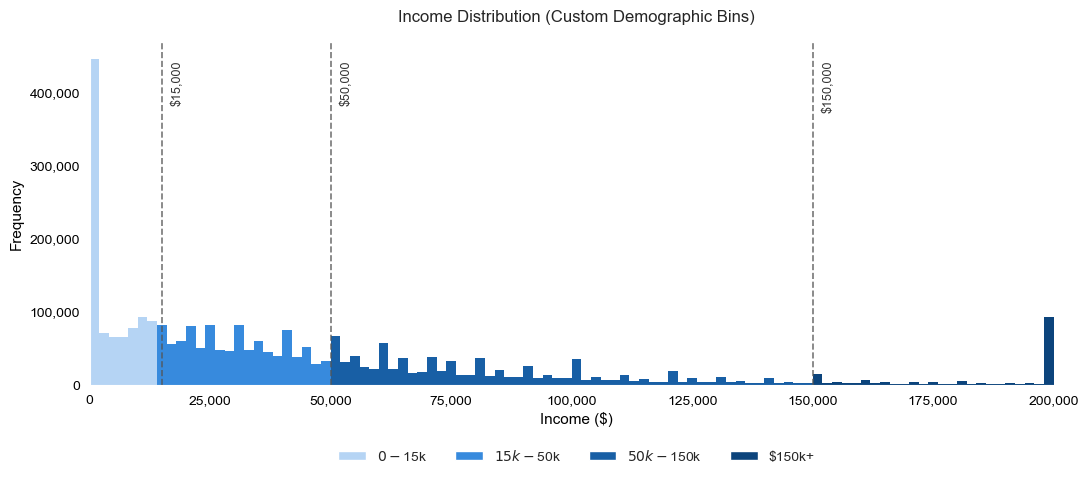

Saved 3a_income_custom_bins.png


In [6]:
CUSTOM_CUTS = [15000, 50000, 150000]
CUSTOM_LABELS = ['$0 - $15k', '$15k - $50k', '$50k - $150k', '$150k+']
CUSTOM_COLORS = ['#B5D4F4', '#378ADD', '#185FA5', '#0C447C']

capped_income = df['PINCP'].dropna().clip(lower=0, upper=200000)

plot_colored_histogram(
    data=capped_income,
    cut_points=CUSTOM_CUTS,
    labels=CUSTOM_LABELS,
    colors=CUSTOM_COLORS,
    title='Income Distribution (Custom Demographic Bins)',
    filename='data-analysis/3a_income_custom_bins.png'
)

=== Educational Attainment Distribution ===
  No HS Diploma: 821,969 (25.09%)
  HS Diploma/GED: 746,974 (22.80%)
  Some College/Assoc.: 794,132 (24.24%)
  Bachelor's+: 913,140 (27.87%)


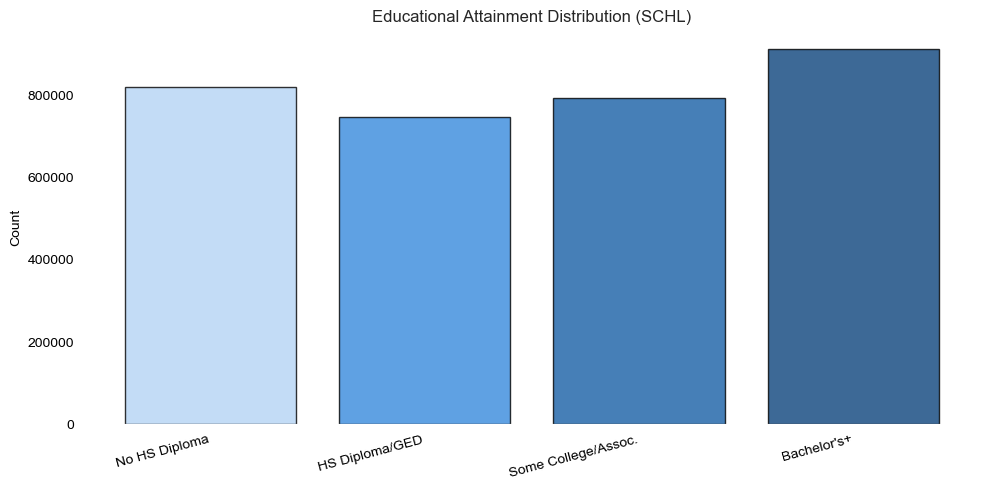

Saved schl_distribution.png


In [20]:
SCHL_BINS = [0, 16, 18, 21, 25]
SCHL_LABELS = ['No HS Diploma', 'HS Diploma/GED', 'Some College/Assoc.', "Bachelor's+"]
SCHL_COLORS = ['#B5D4F4', '#378ADD', '#185FA5', '#0C447C']

df['SCHL_BIN'] = pd.cut(df['SCHL'].dropna(), bins=SCHL_BINS, labels=SCHL_LABELS, right=False)

schl_counts = df['SCHL_BIN'].value_counts().sort_index()
print("=== Educational Attainment Distribution ===")
total = schl_counts.sum()
for label, count in schl_counts.items():
    print(f"  {label}: {count:,} ({count / total * 100:.2f}%)")

# Bar chart
plt.figure(figsize=(10, 5), facecolor='white')
ax = plt.gca()
ax.set_facecolor('white')
bars = ax.bar(schl_counts.index, schl_counts.values,
              color=SCHL_COLORS, edgecolor='black', alpha=0.8)
ax.set_ylabel('Count', color='black')
ax.set_title('Educational Attainment Distribution (SCHL)')
ax.tick_params(colors='black')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('schl_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved schl_distribution.png")

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

age_bins = [0, 25, 45, 65, 98]
age_labels = ['Youth (0-24)', 'Young Adult (25-44)', 'Adult (45-64)', 'Senior (65+)']
df['AGE_BIN'] = pd.cut(df['AGEP'], bins=age_bins, labels=age_labels, right=False)

inc_bins = [-np.inf, 15000, 50000, 150000, np.inf]
inc_labels = ['Low (<15k)', 'Working (15-50k)', 'Middle (50-150k)', 'High (150k+)']
df['INC_BIN'] = pd.cut(df['PINCP'].fillna(0), bins=inc_bins, labels=inc_labels)

df['SEX_LABEL'] = df['SEX'].map({1: 'Male', 2: 'Female'})

if 'SCHL_BIN' not in df.columns:
    schl_bins = [0, 16, 18, 21, 25]
    schl_labels = ['No HS Diploma', 'HS Diploma/GED', 'Some College/Assoc.', "Bachelor's+"]
    df['SCHL_BIN'] = pd.cut(df['SCHL'].dropna(), bins=schl_bins, labels=schl_labels, right=False)

race_col = 'RAC1P' if 'RAC1P' in df.columns else 'RACE'

df['RACE_BINARY'] = df[race_col].apply(lambda x: 'White' if x == 1 else 'Non-White')


def merge_race_6(r):
    if r == 1:
        return 'White'
    elif r == 2:
        return 'Black'
    elif r == 6:
        return 'Asian'
    elif r in [3, 4, 5, 7]:
        return 'Native'
    elif r == 8:
        return 'Other'
    elif r == 9:
        return 'Multi'
    else:
        return 'Other'


df['RACE_6'] = df[race_col].apply(merge_race_6)

RAC1P_LABELS = {
    1: 'White',
    2: 'Black or African American',
    3: 'Native',
    4: 'Native',
    5: 'Native',
    6: 'Asian',
    7: 'Native',
    8: 'Some Other Race',
    9: 'Two or More Races'
}

KeyError: 'SCHL'

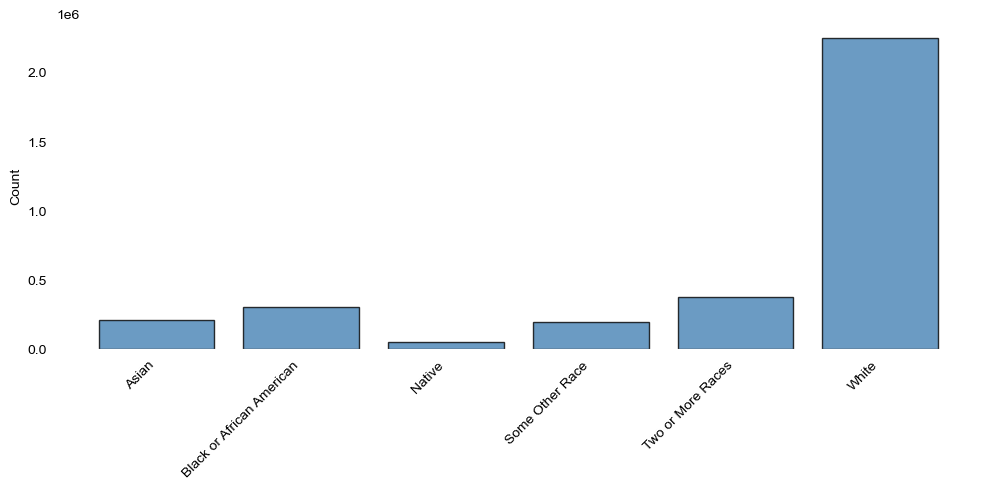

Saved race_detailed-distribution.png


In [7]:
plt.figure(figsize=(10, 5), facecolor='white')

race_counts = df[race_col].value_counts().sort_index()
race_counts.index = race_counts.index.map(RAC1P_LABELS).fillna('Unknown')

race_counts = race_counts.groupby(level=0).sum()

ax = plt.gca()
ax.set_facecolor('white')
bars = ax.bar(race_counts.index, race_counts,
              color="steelblue", edgecolor='black', alpha=0.8)
ax.set_ylabel('Count', color='black')
ax.tick_params(colors='black')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('race_detailed-distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved race_detailed-distribution.png")

In [4]:
def spatial_segregation_analysis(df, group_col, lat_col='Latitude', lon_col='Longitude',
                                 n_lat_bins=20, n_lon_bins=30):
    """
    Compute spatial unevenness of group distributions.
    Returns:
      - dissimilarity_index (for binary) or mean pairwise DI
      - variance of group proportions across spatial bins
      - a DataFrame of per-bin group proportions for plotting
    """
    df_valid = df[[lat_col, lon_col, group_col]].dropna()

    df_valid = df_valid.copy()
    df_valid['lat_bin'] = pd.cut(df_valid[lat_col], bins=n_lat_bins, labels=False)
    df_valid['lon_bin'] = pd.cut(df_valid[lon_col], bins=n_lon_bins, labels=False)
    df_valid['grid_cell'] = df_valid['lat_bin'].astype(str) + '_' + df_valid['lon_bin'].astype(str)

    cell_counts = df_valid.groupby(['grid_cell', group_col]).size().unstack(fill_value=0)
    cell_totals = cell_counts.sum(axis=1)
    cell_props = cell_counts.div(cell_totals, axis=0)

    mask = cell_totals >= 50
    cell_props_filtered = cell_props[mask]
    cell_counts_filtered = cell_counts[mask]
    cell_totals_filtered = cell_totals[mask]

    global_props = df_valid[group_col].value_counts(normalize=True)

    prop_variance = cell_props_filtered.var()

    groups = cell_counts_filtered.columns.tolist()
    T = cell_totals_filtered.sum()

    di_values = {}
    for g in groups:
        T_g = cell_counts_filtered[g].sum()
        if T_g == 0 or T_g == T:
            di_values[g] = 0.0
            continue
        term = np.abs(cell_counts_filtered[g] / T_g -
                      (cell_totals_filtered - cell_counts_filtered[g]) / (T - T_g))
        di_values[g] = 0.5 * term.sum()

    return {
        'prop_variance': prop_variance.to_dict(),
        'dissimilarity_index': di_values,
        'n_cells_used': mask.sum(),
        'global_proportions': global_props.to_dict(),
        'cell_props': cell_props_filtered
    }


features_to_analyze = {
    'Sex': ('SEX_LABEL', 2),
    'Race (Binary)': ('RACE_BINARY', 2),
    'Age': ('AGE_BIN', 4),
    'Income': ('INC_BIN', 4),
    'Race (6-bin)': ('RACE_6', 6),
    'Age x Sex': ('AGE_SEX', 8),
    'Race (6-bin) x Sex': ('RACE6_SEX', 12),
}

K_FOR_CLT = 10
CLT_TARGET = 30

segregation_results = {}
rows = []

for name, (col, L_declared) in features_to_analyze.items():
    result = spatial_segregation_analysis(df, col)
    segregation_results[name] = result

    di_per_group = result['dissimilarity_index']
    mean_di = float(np.mean(list(di_per_group.values())))

    global_props = result['global_proportions']
    p_min = min(global_props.values())
    smallest_group = min(global_props, key=global_props.get)
    L_observed = len(global_props)

    n_clt = int(np.ceil(CLT_TARGET * K_FOR_CLT / p_min))

    rows.append({
        'Feature': name,
        'Column': col,
        'L_declared': L_declared,
        'L_observed': L_observed,
        'mean_DI': round(mean_di, 4),
        'smallest': smallest_group,
        'p_min': round(p_min, 5),
        'n_CLT(k=10)': n_clt,
        'cells_used': int(result['n_cells_used']),
    })

    print(f"\n{'=' * 72}")
    print(f"Feature: {name}  ({col})  |  L={L_observed}  |  cells used: {result['n_cells_used']}")
    print(f"  mean DI = {mean_di:.4f}")
    print(f"  smallest group = '{smallest_group}'  (p_min = {p_min:.5f})")
    print(f"  n_CLT floor (k={K_FOR_CLT}, target 30 per cell) = {n_clt:,}")
    print(f"  per-group DI:")
    for g, di in sorted(di_per_group.items(), key=lambda kv: -kv[1]):
        share = global_props.get(g, float('nan'))
        print(f"    {str(g):40s}  DI={di:.4f}   share={share:.4f}")

summary_df = pd.DataFrame(rows).sort_values('mean_DI').reset_index(drop=True)
print("\n=== Summary table (for thesis §0.3.9 and Eval 3 design) ===")
print(summary_df.to_string(index=False))
summary_df.to_csv('di_summary.csv', index=False)


Feature: Sex  (SEX_LABEL)  |  L=2  |  cells used: 140
  mean DI = 0.0151
  smallest group = 'Male'  (p_min = 0.48724)
  n_CLT floor (k=10, target 30 per cell) = 616
  per-group DI:
    Female                                    DI=0.0151   share=0.5128
    Male                                      DI=0.0151   share=0.4872

Feature: Race (Binary)  (RACE_BINARY)  |  L=2  |  cells used: 140
  mean DI = 0.2909
  smallest group = 'Non-White'  (p_min = 0.31830)
  n_CLT floor (k=10, target 30 per cell) = 943
  per-group DI:
    Non-White                                 DI=0.2909   share=0.3183
    White                                     DI=0.2909   share=0.6817


C:\Users\Peete\AppData\Local\Temp\ipykernel_21944\3380399424.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_counts = df_valid.groupby(['grid_cell', group_col]).size().unstack(fill_value=0)



Feature: Age  (AGE_BIN)  |  L=4  |  cells used: 140
  mean DI = 0.0444
  smallest group = 'Youth (0-24)'  (p_min = 0.14340)
  n_CLT floor (k=10, target 30 per cell) = 2,092
  per-group DI:
    Senior (65+)                              DI=0.0612   share=0.2649
    Young Adult (25-44)                       DI=0.0525   share=0.2831
    Youth (0-24)                              DI=0.0429   share=0.1434
    Adult (45-64)                             DI=0.0211   share=0.3086


C:\Users\Peete\AppData\Local\Temp\ipykernel_21944\3380399424.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_counts = df_valid.groupby(['grid_cell', group_col]).size().unstack(fill_value=0)



Feature: Income  (INC_BIN)  |  L=4  |  cells used: 140
  mean DI = 0.0983
  smallest group = 'High (150k+)'  (p_min = 0.05216)
  n_CLT floor (k=10, target 30 per cell) = 5,752
  per-group DI:
    High (150k+)                              DI=0.1885   share=0.0522
    Middle (50-150k)                          DI=0.0745   share=0.2620
    Working (15-50k)                          DI=0.0710   share=0.3465
    Low (<15k)                                DI=0.0593   share=0.3393

Feature: Race (6-bin)  (RACE_6)  |  L=6  |  cells used: 140
  mean DI = 0.3453
  smallest group = 'Native'  (p_min = 0.01385)
  n_CLT floor (k=10, target 30 per cell) = 21,655
  per-group DI:
    Native                                    DI=0.4215   share=0.0139
    Asian                                     DI=0.3985   share=0.0618
    Other                                     DI=0.3687   share=0.0546
    Black                                     DI=0.3347   share=0.0890
    White                                     

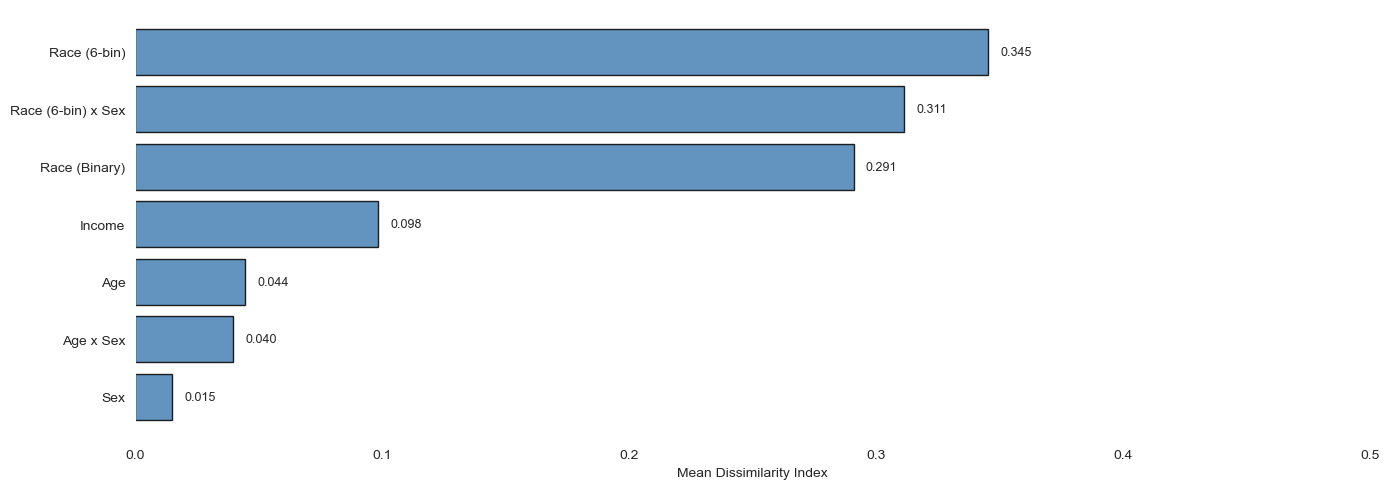

In [5]:
order = sorted(segregation_results.items(),
               key=lambda kv: np.mean(list(kv[1]['dissimilarity_index'].values())))
labels = [name for name, _ in order]
values = [np.mean(list(res['dissimilarity_index'].values())) for _, res in order]

fig, ax = plt.subplots(figsize=(14, 5), facecolor='white')
ax.set_facecolor('white')
ax.barh(labels, values, color='steelblue', edgecolor='black', alpha=0.85)
ax.set_xlabel('Mean Dissimilarity Index')
ax.set_xlim(0, max(max(values) * 1.1, 0.5))
for i, v in enumerate(values):
    ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('mean_di_index.png', dpi=150, bbox_inches='tight')
plt.show()